# 工場の稼働能力対スループット:PROC SGPLOTによる2次元ポートフォリオ分析

## エグゼクティブサマリー

離散型製造の生産ポートフォリオには、すべての製造ラインについて同時に重要な2つの数字がある:**どれだけの機械稼働能力を消費するか**と**実際にどれだけの良品を産出するか**である。1次元の棒グラフではそのどちらか一方しか示せない。このノートブックは`PROC SGPLOT`を使ってこの両方を同時に可視化し、中心となるビューとして**バブルプロット**を用いる——各ラインは稼働能力(x)とスループット(y)で位置づけられ、バブルの大きさが生産性(機械稼働時間当たりの生産数)を表す。右下に位置するライン(稼働能力が大きく産出が少ない)は能力の無駄遣いラインであり、左上に位置し大きなバブルを持つラインは高収率である。グループ化された棒グラフビューは工場別にスループットを分解し、生産性ランキングがそのギャップを裏付ける。

実際に実行した出力(3工場にまたがる8製造ライン、100件のシフト別実績を24のライン×工場セルに集約)に基づくと、**鋳造(Casting)**が最も明確な能力の無駄遣いライン(機械稼働時間当たり14.3良品——総稼働能力の10.1%を消費しながら良品のわずか3.2%しか産出しない)であり、一方**梱包(Packaging)**が突出した高収率ライン(時間当たり119.2ユニット——稼働能力の9.1%が産出の23.8%を生む)である。工場別では**シュツットガルト(Stuttgart)**が時間当たり49.9ユニットで最も高稼働、**モンテレー(Monterrey)**が41.6で最も低い。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | 8製造ライン、3工場、3シフトにわたる合成シフト別生産実績——計画機械稼働時間、実稼働時間、ダウンタイム、総生産数/不良数/良品数(unlicensedモードでは100件に制限) | 100 |
| WORK.LINE_CAPACITY | 製造ライン×工場別の集計:稼働能力時間合計(x)、良品生産数(y)、合格品歩留まり% | 24 |

*すべてのデータは合成であり、固定シードでノートブック内に生成される——外部ファイルもネットワークも使用しない。*

# 工場の稼働能力対スループット分析

**領域:** 離散型製造 — オペレーションズ/生産工学

**プロシジャ:** `PROC SGPLOT`(ODS統計グラフィックス)

従来の棒グラフはカテゴリごとに1つの応答しか示せない。生産ポートフォリオを**2つ**の数値次元——*各製造ラインがどれだけの稼働能力を消費するか*対*実際にどれだけの産出を届けるか*——で同時に比較するには、両方を同じキャンバスに配置するプロットが必要である。`PROC SGPLOT`の`BUBBLE`ステートメントはまさにそれを行う:各ラインを稼働能力(x)と良品数(y)で位置づけ、3つ目の指標である生産性でバブルの大きさを決定する。右に寄っていて低い位置にあるラインは能力の無駄遣いラインであり、左上にあって大きなバブルを持つラインは守るべき高収率ラインである。このノートブックは現実的な合成生産データセットを構築し、バブルプロット、工場別グループ棒グラフ、単一工場の詳細分析、そして横並びのクラスタ工場比較を通じてSGPLOTを動かす。

> **PROC GAREABARについての注記。** 1本の**棒**に2次元を符号化する古典的なSAS/GRAPHの方法は`PROC GAREABAR`(棒の幅で1変数、高さでもう1変数を符号化するActiveX専用の面積棒グラフ)である。GAREABARは**このJennerビルドにはまだ実装されていない**——このギャップはバンク済みテスト`tests/400996_nb_gareabar_unimplemented`で追跡されている。このノートブックは、完全にサポートされている`PROC SGPLOT`で同じ分析目標に到達する。そのバブルビューとグループ棒グラフビューは、稼働能力対スループットという同一のストーリーを伝える。

## 1. 合成の生産データを生成する

3工場からなる離散型製造ネットワークについて、6週間分のシフト別生産実績をシミュレートする。各製造ラインには基準サイクルタイムと不良率があり、スループットは計画機械稼働時間、ライン固有の効率、そしてランダムなダウンタイムによって決まる。`call streaminit`でシードを固定するため、ノートブックは完全に再現可能である——外部ファイルもネットワークも使用しない。

In [1]:
/* --------------------------------------------------------
   合成シフト別生産実績
   8製造ライン x 3工場 x 3シフト x 約10日間
   幅変数  = 計画機械稼働時間(稼働能力)
   応答    = 良品生産数(スループット)
   -------------------------------------------------------- */
データ work.production_runs;
    呼出 streaminit(20260531);
    長さ product_line $30 plant $30 shift $12;

    /* ラインごとの機械稼働時間当たりの標準生産数 */
    配列 line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* ラインごとの基準不良率 */
    配列 line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    /* 工場別の効率係数 */
    配列 plant_eff[3] _temporary_ (1.00 0.92 1.08);
    配列 shift_eff[3] _temporary_ (1.00 0.95 0.88);

    繰返 day = 1 から 10;
        繰返 li = 1 から 8;
            繰返 pi = 1 から 3;
                繰返 si = 1 から 3;
                    もし      li = 1 なら product_line = "プレス加工";
                    他 もし li = 2 なら product_line = "溶接";
                    他 もし li = 3 なら product_line = "機械加工";
                    他 もし li = 4 なら product_line = "鋳造";
                    他 もし li = 5 なら product_line = "射出成形";
                    他 もし li = 6 なら product_line = "組立";
                    他 もし li = 7 なら product_line = "仕上げ";
                    他                 product_line = "梱包";

                    もし      pi = 1 なら plant = "デトロイト";
                    他 もし pi = 2 なら plant = "モンテレー";
                    他                plant = "シュツットガルト";

                    もし      si = 1 なら shift = "昼勤";
                    他 もし si = 2 なら shift = "夕勤";
                    他                shift = "夜勤";

                    /* このシフトの計画機械稼働時間 */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* 計画外のダウンタイムが稼働能力を圧迫する */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* ノイズを伴う実効スループット率 */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    出力;
                終了;
            終了;
        終了;
    終了;
    保持 run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    書式 run_date date9.;
実行;

処理 印刷 データ=work.production_runs(obs=8) noobs;
    見出 product_line="製造ライン" plant="工場" shift="シフト"
          sched_hours="計画稼働時間" run_hours="実稼働時間"
          downtime_hours="ダウンタイム時間" gross_units="総生産数"
          scrap_units="不良数" good_units="良品数" run_date="稼働日";
    表題 "合成シフト別生産実績のサンプル";
実行;
表題;


                                                    合成シフト別生産実績のサンプル                                                     

      稼働日            製造ライン                        工場        シフト              計画稼働時間            実稼働時間                  ダウンタイム時間          総生産数        不良数        良品数
05JAN2026  プレス加工            デトロイト                     昼勤                        7.8              6.7                       1.1           306         14        292
05JAN2026  プレス加工            デトロイト                     夕勤                        6.8              6.5                       0.3           259         12        247
05JAN2026  プレス加工            デトロイト                     夜勤                          8              7.6                       0.4           269         11        258
05JAN2026  プレス加工            モンテレー                     昼勤                        7.9              6.8                       1.1           283         12        271
05JAN2026  プレス加工            モンテレー                     夕勤       


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.23 seconds
  cpu   0.23 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. ライン×工場レベルに集計する

プロットはカテゴリごとに1点を比較するため、シフトレベルの詳細を製造ライン×工場別の集計に積み上げる。`total_capacity`(計画機械稼働時間の合計)が**x**次元に、`good_units`(合格産出数の合計)が**y**次元になり、`units_per_hr`(良品数÷稼働時間)がバブルの大きさを決める生産性となる。`plant`は後でグルーピング変数として使えるよう保持する。また、ポートフォリオのバブルプロット用に(工場を横断した)ライン別の集計も作成する。

In [2]:
/* --------------------------------------------------------
   製造ライン x 工場に集計する
   total_capacity -> x (稼働能力時間)
   good_units     -> y (スループット)
   units_per_hr   -> バブルサイズ(生産性)
   -------------------------------------------------------- */
処理 平均 データ=work.production_runs NOPRINT NWAY;
    分類 product_line plant;
    変数 sched_hours good_units scrap_units;
    出力 out=work.line_capacity(削除=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
実行;

データ work.line_capacity;
    設定 work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    書式 units_per_hr 6.1 yield_pct 5.1;
実行;

処理 並替 データ=work.line_capacity;
    基準 product_line plant;
実行;

/* ライン別の集計(全工場を横断)、ポートフォリオビュー用 */
処理 平均 データ=work.line_capacity NOPRINT NWAY;
    分類 product_line;
    変数 total_capacity good_units;
    出力 out=work.line_total(削除=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
実行;

データ work.line_total;
    設定 work.line_total;
    units_per_hr = good_units / total_capacity;
    書式 units_per_hr 6.1;
実行;

処理 並替 データ=work.line_total;
    基準 units_per_hr;
実行;

処理 印刷 データ=work.line_total noobs;
    変数 product_line total_capacity good_units units_per_hr;
    見出 product_line="製造ライン" total_capacity="稼働時間合計"
          good_units="良品数合計" units_per_hr="時間当たり生産数";
    表題 "生産性ランキング(機械稼働時間当たり良品数)";
実行;
表題;


                                                 生産性ランキング(機械稼働時間当たり良品数)                                                 

          製造ライン              稼働時間合計            良品数合計                  時間当たり生産数
鋳造                             73.4             1050                      14.3
溶接                            130.8             3038                      23.2
機械加工                          128.9             3762                      29.2
プレス加工                         130.7             4713                      36.1
射出成形                           66.2             3430                      51.8
組立                             67.3             4289                      63.7
仕上げ                            64.6             4927                      76.3
梱包                             65.9             7855                     119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. ODSグラフィックス出力先を開く

`PROC SGPLOT`はODS統計グラフィックスを通じて描画する。各プロットが画像として出力されるよう`ODS HTML`出力先を開き、`ODS GRAPHICS ON`を有効にする。ActiveX専用のSAS/GRAPHプロシジャと異なり、SGPLOTはデバイスに依存しないため、特別なデバイスドライバは不要である。

In [3]:
ODS html;
ODS GRAPHICS ON;



NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. ポートフォリオのバブルプロット — 稼働能力対スループット

中心となるビュー:`BUBBLE x=total_capacity y=good_units size=units_per_hr`。各製造ラインは1つのバブルとして、稼働能力時間合計(x)と良品数合計(y)で位置づけられ、バブルの面積は生産性に応じて拡大縮小される。`DATALABEL=`は各バブルの横にライン名を表示する。これは工場マネージャーが求める2次元比較である——能力の無駄遣いラインは**右下**(稼働時間が多く産出が少なく、バブルが小さい)に落ち、高収率ラインは**左上**(稼働時間が少なく産出が多く、バブルが大きい)に上がる。

                                                生産ポートフォリオ - 稼働能力対スループット                                                 
                                         x = 計画機械稼働時間、y = 良品数、バブルサイズ = 時間当たり生産数                                         


右下 = 能力の無駄遣いライン、左上で大きいバブル = 高収率ライン。



NOTE: Option TITLE changed to 生産ポートフォリオ - 稼働能力対スループット.
NOTE: Option TITLE2 changed to x = 計画機械稼働時間、y = 良品数、バブルサイズ = 時間当たり生産数.
NOTE: Option FOOTNOTE changed to 右下 = 能力の無駄遣いライン、左上で大きいバブル = 高収率ライン。.
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


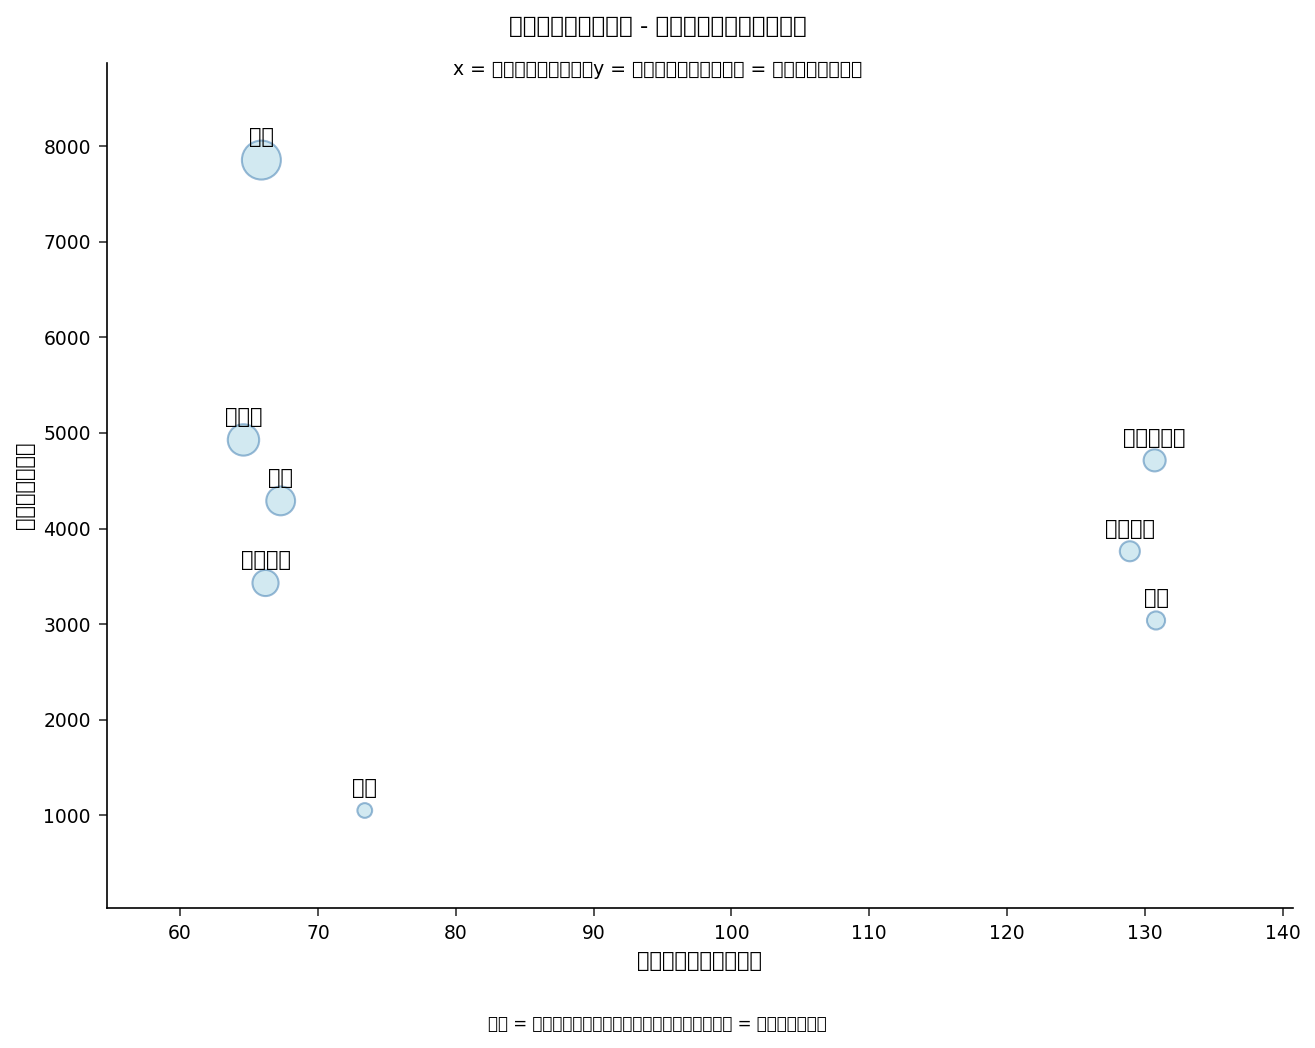

In [4]:
表題 "生産ポートフォリオ - 稼働能力対スループット";
title2 "x = 計画機械稼働時間、y = 良品数、バブルサイズ = 時間当たり生産数";
footnote JUSTIFY=LEFT
    "右下 = 能力の無駄遣いライン、左上で大きいバブル = 高収率ライン。";

処理 SGPLOT データ=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS 見出="計画機械稼働時間合計";
    YAXIS 見出="良品生産数合計";
実行;

表題; title2; footnote;


## 5. ライン別スループットを工場別に分解する

各ラインの産出が3つの工場にどう分かれるかを見るため、`VBAR product_line / response=good_units group=plant`チャートは各棒の中で工場ごとの寄与を積み上げる。これはセグメンテーションビューである:棒の合計高さ(ライン別良品数)と棒内の工場構成の両方を示すため、特定の工場が産出を支配しているラインを見つけられる。

                                                   製造ライン別良品数(工場別積み上げ)                                                   
                                                棒の高さ = 良品数合計、区分 = 工場別内訳                                                 




NOTE: Option TITLE changed to 製造ライン別良品数(工場別積み上げ).
NOTE: Option TITLE2 changed to 棒の高さ = 良品数合計、区分 = 工場別内訳.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


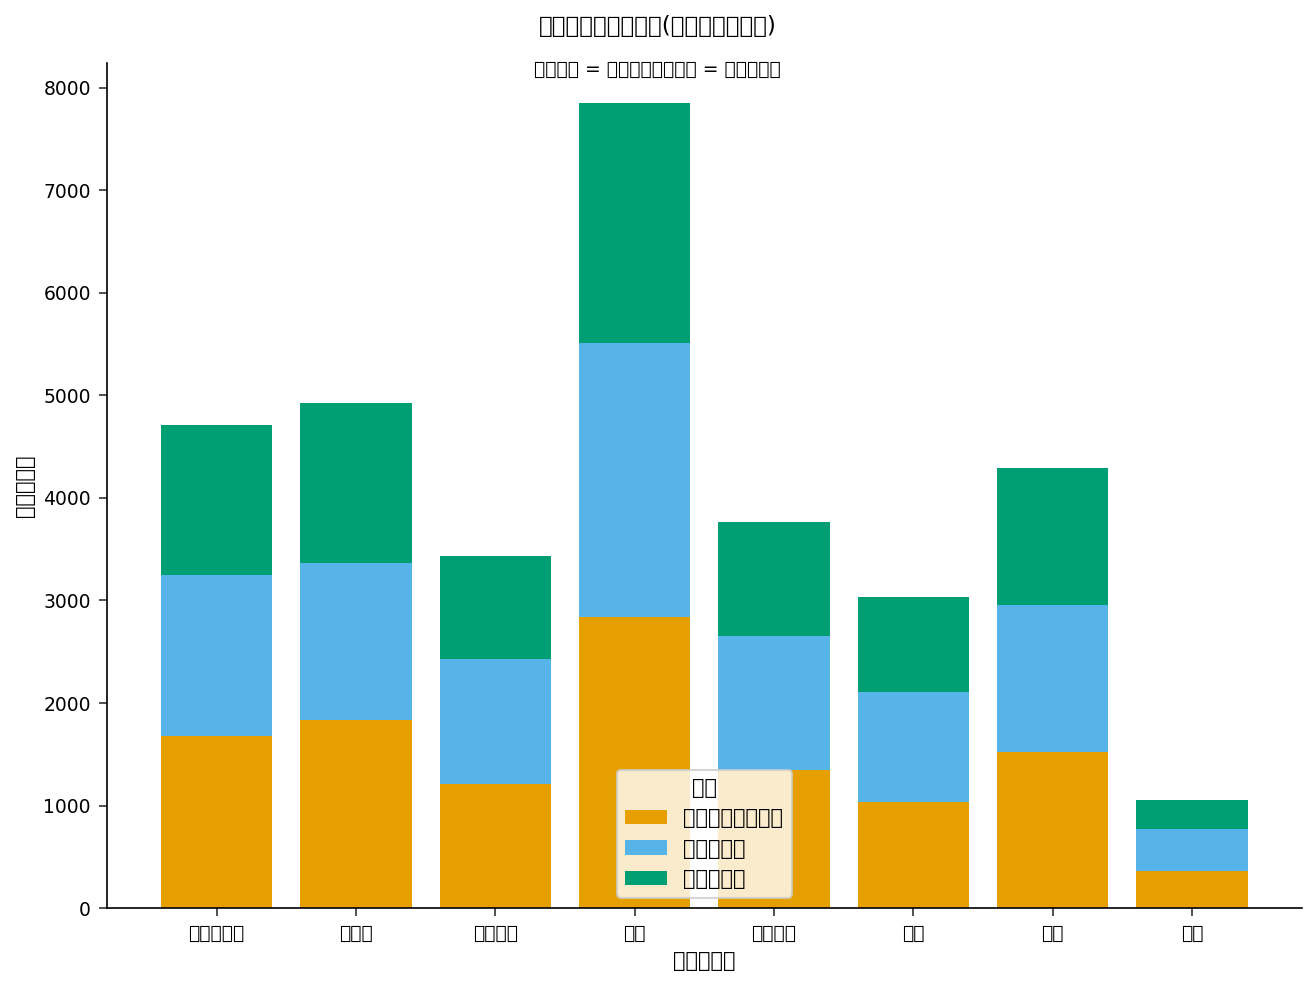

In [5]:
表題 "製造ライン別良品数(工場別積み上げ)";
title2 "棒の高さ = 良品数合計、区分 = 工場別内訳";

処理 SGPLOT データ=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS 見出="製造ライン" fitpolicy=ROTATE;
    YAXIS 見出="良品生産数";
    keylegend / 表題="工場" position=bottom;
実行;

表題; title2;


## 6. 単一工場の生産性詳細分析(WHERE)

長い製造ライン名には水平棒(`HBAR`)が適している。`WHERE`句でシュツットガルト工場に絞り込み、`units_per_hr`で棒を描画することで、チャートはシュツットガルトのラインを生産性でランク付けする。入力はレートの昇順にソートされているため、最も生産性の低いラインが下に、最も高いラインが上に位置する。

                                                 シュツットガルト工場 - 生産性ランキング                                                  


棒の長さ = 機械稼働時間当たり良品数(単一工場の詳細分析)。



NOTE: Option TITLE changed to シュツットガルト工場 - 生産性ランキング.
NOTE: Option FOOTNOTE changed to 棒の長さ = 機械稼働時間当たり良品数(単一工場の詳細分析)。.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


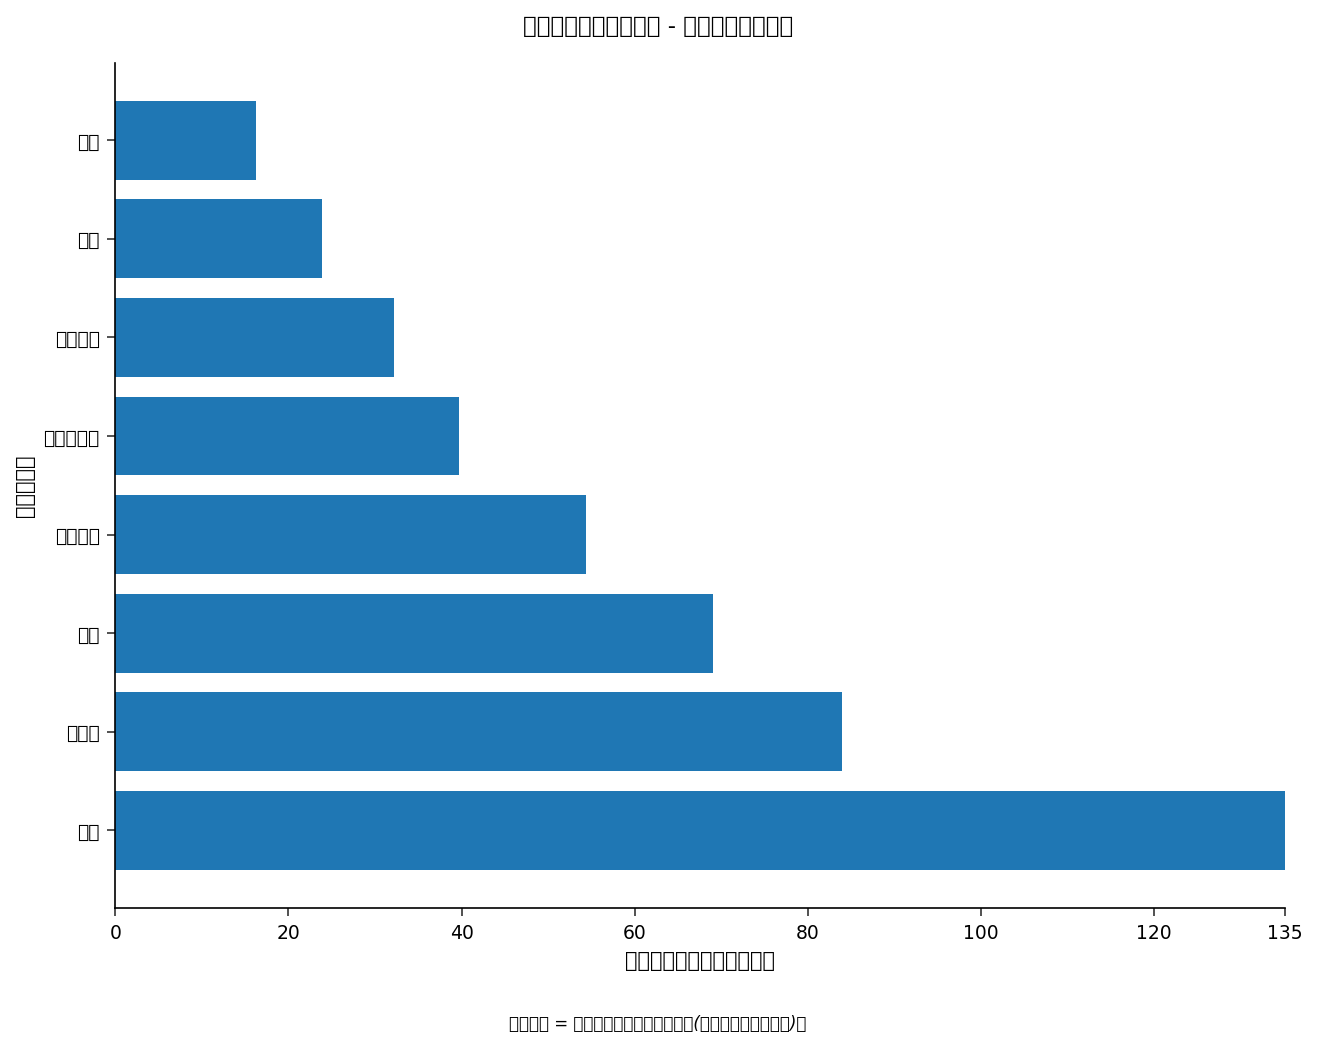

In [6]:
表題 "シュツットガルト工場 - 生産性ランキング";
footnote JUSTIFY=LEFT "棒の長さ = 機械稼働時間当たり良品数(単一工場の詳細分析)。";

処理 SGPLOT データ=work.line_capacity;
    条件 plant = "シュツットガルト";
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS 見出="機械稼働時間当たり良品数";
    YAXIS 見出="製造ライン";
実行;

表題; footnote;


## 7. 工場別の横並び比較(クラスタ棒グラフ)

3工場をライン別に比較するため、クラスタ棒グラフ(`GROUPDISPLAY=CLUSTER`)はデトロイト、モンテレー、シュツットガルトを各製造ラインの中で隣接する棒として描画する。これは公平な工場比較のビューである:どのラインについても、どの工場が最も多くの良品を産出したかを読み取ることができ、工場効率の差(シュツットガルトが最高、モンテレーが最低)が直接見える。

                                                  ライン別・工場別良品数 - 横並び比較                                                   
                                                  クラスタ棒グラフ:各製造ラインの工場別棒                                                  




NOTE: Option TITLE changed to ライン別・工場別良品数 - 横並び比較.
NOTE: Option TITLE2 changed to クラスタ棒グラフ:各製造ラインの工場別棒.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


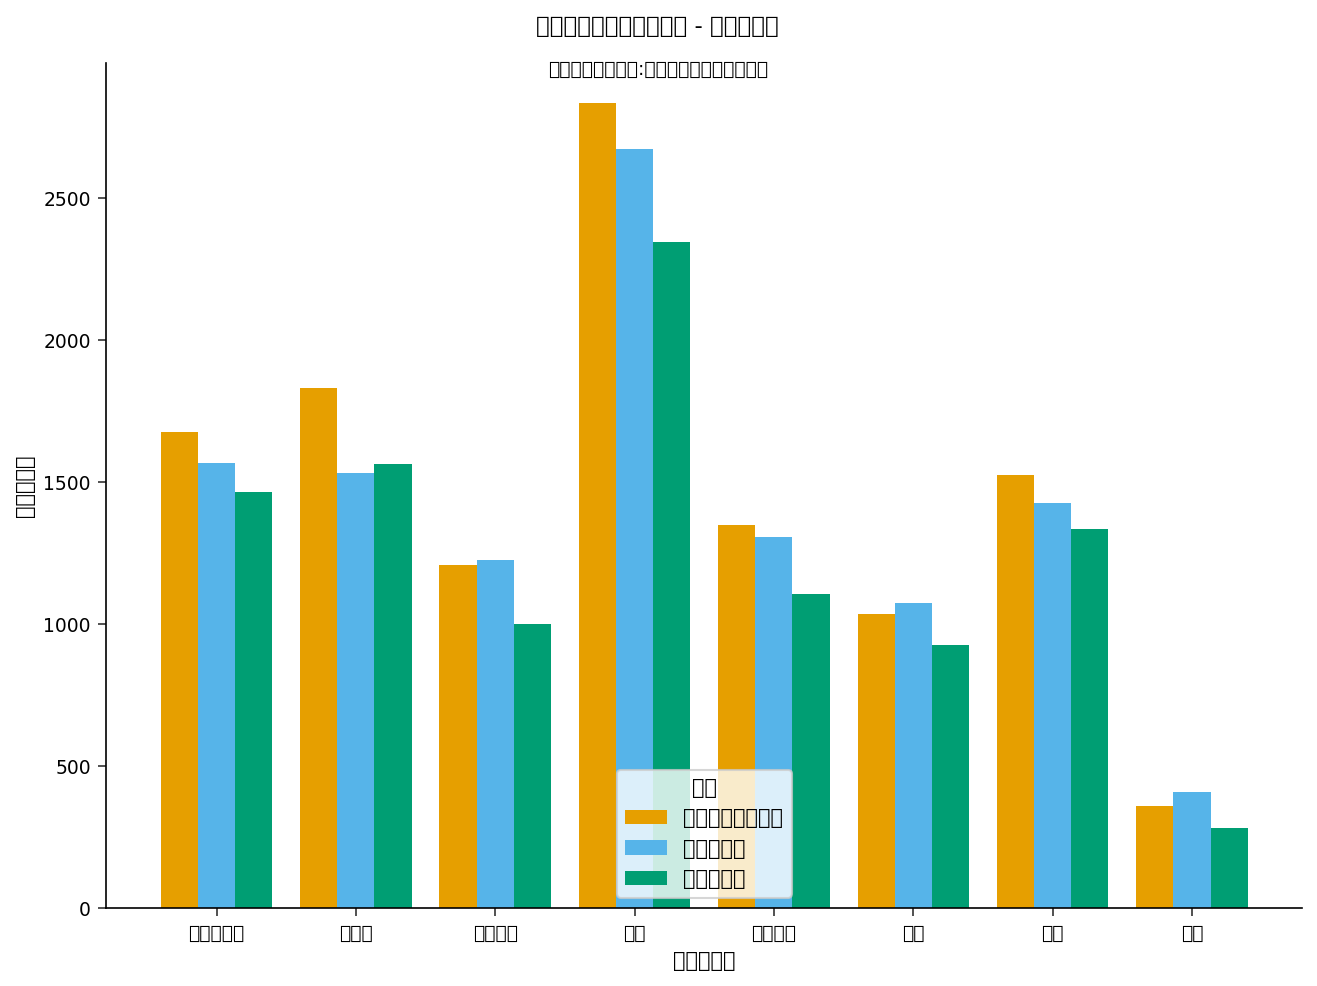

In [7]:
表題 "ライン別・工場別良品数 - 横並び比較";
title2 "クラスタ棒グラフ:各製造ラインの工場別棒";

処理 SGPLOT データ=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=群;
    XAXIS 見出="製造ライン" fitpolicy=ROTATE;
    YAXIS 見出="良品生産数";
    keylegend / 表題="工場" position=bottom;
実行;

表題; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;


## 解釈

稼働能力とスループットを同じ軸上にプロットすることで、1次元の棒グラフでは隠れてしまう関係が明らかになる。**鋳造(Casting)**はポートフォリオの中で最も明確な能力の無駄遣いラインである:生産性ランキングでは最下位の**機械稼働時間当たり14.3良品**に位置し、バブルプロットでは小さなバブルとして左下に落ちる——計画稼働時間合計の**10.1%**を消費しながら良品の**3.2%**しか産出しない(不良率が高いため歩留まりも最低の約91%である)。サイクルタイム短縮と不良削減の改善(カイゼン)の最有力候補である。対極にあるのが**梱包(Packaging)**で、**機械稼働時間当たり119.2ユニット**という突出した高収率ラインである——スループット軸上で高く大きなバブルを持ち、稼働能力の**9.1%**を全良品数の**23.8%**に変える。稼働率を守ることで不釣り合いなほどの産出が得られる。**仕上げ(Finishing)**(時間当たり76.3ユニット)と**組立(Assembly)**(63.7)も同じ高収率パターンに従う。

このパターンは体系的である:低速で稼働能力を多く消費する上流の4ライン——鋳造、溶接(時間当たり23.2ユニット)、機械加工(29.2)、プレス加工(36.1)——は合わせて計画稼働時間の約**64%**を消費するが、良品の約**38%**しか産出しない。一方、下流の高速な4ラインは消費する時間に対して過剰なほど産出する。工場別積み上げビューと横並びのクラスタ棒グラフは、この背景にある工場次元を示す:**シュツットガルト(Stuttgart)**が**機械稼働時間当たり49.9良品**で最も高稼働、**デトロイト(Detroit)**が**44.9**で中位、**モンテレー(Monterrey)**が**41.6**で最下位である——モンテレーのモデル化されたダウンタイムが高いことと整合する。運用上は、計画稼働時間を高収率の下流ラインへ再配分すること、そしてモンテレーのダウンタイムをシュツットガルトの実践と比較検証することが示唆される。

*合成データのみ——数値はPROC SGPLOTによる2次元の稼働能力対スループット可視化の例示であり、実際の工場実績ではない。*